In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('data/case1Data.csv')
X_test = pd.read_csv('data/case1Data_Xnew.csv')

In [3]:
y = data['y']
X = data.drop('y', axis=1)

#categorical features
cat_cols = ["C_01", "C_02", "C_03", "C_04", "C_05"]


for c in cat_cols:
    X[c] = X[c].astype("string")
    X[c] = X[c].fillna("Missing")
    X[c] = X[c].astype("category")       

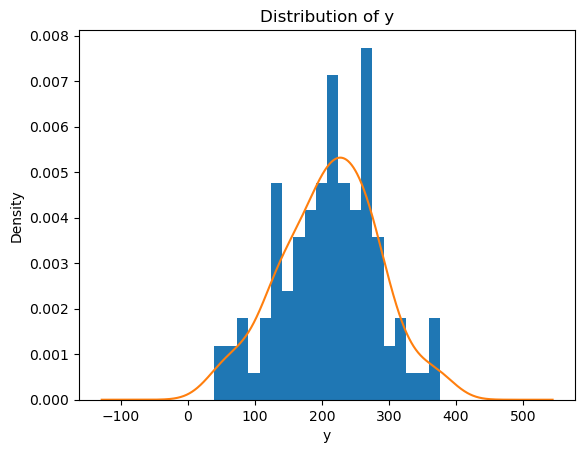

In [4]:

plt.figure()
pd.Series(y).plot(kind="hist", bins=20, density=True)
pd.Series(y).plot(kind="kde")
plt.xlabel("y")
plt.title("Distribution of y")
plt.show()

In [8]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

cat_cols = ["C_01", "C_02", "C_03", "C_04", "C_05"]

selected_num_features = [c for c in selected_features if c not in cat_cols]
use_cols = selected_num_features + cat_cols

X_model = X[use_cols].copy()
X_test_model = X_test[use_cols].copy()

# categorical handling
for c in cat_cols:
    X_model[c] = X_model[c].astype("string").fillna("Missing").astype("category")
    X_test_model[c] = X_test_model[c].astype("string").fillna("Missing").astype("category")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros(len(X_model))
test_preds = np.zeros(len(X_test_model))
fold_rmses = []
best_iters = []

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 5,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "lambda": 10.0,
    "alpha": 0.0,
    "tree_method": "hist",
    "seed": 42,
}

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_model), 1):
    X_tr, X_va = X_model.iloc[tr_idx], X_model.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    dtr = xgb.DMatrix(X_tr, label=y_tr, enable_categorical=True)
    dva = xgb.DMatrix(X_va, label=y_va, enable_categorical=True)
    dte = xgb.DMatrix(X_test_model, enable_categorical=True)

    booster = xgb.train(
        params,
        dtr,
        num_boost_round=5000,
        evals=[(dva, "val")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )

    pred_va = booster.predict(dva, iteration_range=(0, booster.best_iteration + 1))
    oof[va_idx] = pred_va

    rmse = np.sqrt(mean_squared_error(y_va, pred_va))
    fold_rmses.append(rmse)
    best_iters.append(booster.best_iteration)

    test_preds += booster.predict(
        dte, iteration_range=(0, booster.best_iteration + 1)
    ) / kf.n_splits

print("Fold RMSEs:", fold_rmses)
print("OOF RMSE  :", np.sqrt(mean_squared_error(y, oof)))
print("Fold RMSE std:", np.std(fold_rmses))
print("Best iters:", best_iters, "median:", int(np.median(best_iters)))

Fold RMSEs: [np.float64(51.06344995482697), np.float64(39.438494301745386), np.float64(27.837043819176664), np.float64(54.131199753684484), np.float64(51.41106279739456)]
OOF RMSE  : 45.849876613573606
Fold RMSE std: 9.86400578824953
Best iters: [1730, 1425, 4993, 1035, 744] median: 1425


In [ ]:


from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

cat_cols = ["C_01", "C_02", "C_03", "C_04", "C_05"]

alphas = []
l1_ratios = []
nonzero_counts = []
# -----------------------------
# Feature sets
# -----------------------------
selected_num_features = [c for c in selected_features if c not in cat_cols]
reduced_cols = selected_num_features + cat_cols
full_cols = X.columns.tolist()

X_reduced = X[reduced_cols].copy()
X_full = X[full_cols].copy()

# -----------------------------
# categorical handling for XGBoost
# -----------------------------
for c in cat_cols:
    if c in X_reduced.columns:
        X_reduced[c] = X_reduced[c].astype("string").fillna("Missing").astype("category")

    if c in X_full.columns:
        X_full[c] = X_full[c].astype("string").fillna("Missing").astype("category")

# -----------------------------
# ElasticNet dataset
# Use reduced feature set for fairer comparison
# one-hot encode categoricals
# -----------------------------
X_en = X[reduced_cols].copy()

for c in cat_cols:
    if c in X_en.columns:
        X_en[c] = X_en[c].astype("string").fillna("Missing")

X_en = pd.get_dummies(X_en, dummy_na=True).astype(float)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "learning_rate": 0.03,
    "max_depth": 3,
    "min_child_weight": 5,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "lambda": 10.0,
    "alpha": 0.0,
    "tree_method": "hist",
    "seed": 42,
}

# storage
oof_reduced = np.zeros(len(X))
oof_full = np.zeros(len(X))
oof_en = np.zeros(len(X))

fold_rmses_reduced = []
fold_rmses_full = []
fold_rmses_en = []

best_iters_reduced = []
best_iters_full = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X), 1):

    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    # =====================
    # Reduced XGBoost
    # =====================
    X_tr_red, X_va_red = X_reduced.iloc[tr_idx], X_reduced.iloc[va_idx]

    dtr_red = xgb.DMatrix(X_tr_red, label=y_tr, enable_categorical=True)
    dva_red = xgb.DMatrix(X_va_red, label=y_va, enable_categorical=True)

    booster_red = xgb.train(
        params,
        dtr_red,
        num_boost_round=5000,
        evals=[(dva_red, "val")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )

    pred_red = booster_red.predict(
        dva_red, iteration_range=(0, booster_red.best_iteration + 1)
    )

    oof_reduced[va_idx] = pred_red
    rmse_red = np.sqrt(mean_squared_error(y_va, pred_red))
    fold_rmses_reduced.append(rmse_red)
    best_iters_reduced.append(booster_red.best_iteration)

    # =====================
    # Full XGBoost
    # =====================
    X_tr_full, X_va_full = X_full.iloc[tr_idx], X_full.iloc[va_idx]

    dtr_full = xgb.DMatrix(X_tr_full, label=y_tr, enable_categorical=True)
    dva_full = xgb.DMatrix(X_va_full, label=y_va, enable_categorical=True)

    booster_full = xgb.train(
        params,
        dtr_full,
        num_boost_round=5000,
        evals=[(dva_full, "val")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )

    pred_full = booster_full.predict(
        dva_full, iteration_range=(0, booster_full.best_iteration + 1)
    )

    oof_full[va_idx] = pred_full
    rmse_full = np.sqrt(mean_squared_error(y_va, pred_full))
    fold_rmses_full.append(rmse_full)
    best_iters_full.append(booster_full.best_iteration)

    # =====================
    # ElasticNet
    # =====================
    X_tr_en, X_va_en = X_en.iloc[tr_idx], X_en.iloc[va_idx]

    model_en = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("elastic", ElasticNetCV(
            l1_ratio=[0.2, 0.5, 0.8, 0.9, 1.0],
            cv=5,
            max_iter=10000
        ))
    ])

    model_en.fit(X_tr_en, y_tr)
    
    alphas.append(model_en.named_steps["elastic"].alpha_)
    l1_ratios.append(model_en.named_steps["elastic"].l1_ratio_)


    # count nonzero coefficients
    nonzero = np.sum(np.abs(model_en.named_steps["elastic"].coef_) > 1e-6)
    nonzero_counts.append(nonzero)

    pred_en = model_en.predict(X_va_en)

    oof_en[va_idx] = pred_en
    rmse_en = np.sqrt(mean_squared_error(y_va, pred_en))
    fold_rmses_en.append(rmse_en)

    print(
        f"Fold {fold}: "
        f"reduced={rmse_red:.2f}, "
        f"full={rmse_full:.2f}, "
        f"elastic={rmse_en:.2f}"
    )

# -----------------------------
# Results
# -----------------------------
rmse_reduced = np.sqrt(mean_squared_error(y, oof_reduced))
rmse_full = np.sqrt(mean_squared_error(y, oof_full))
rmse_en = np.sqrt(mean_squared_error(y, oof_en))

print("\n--- REDUCED XGBOOST ---")
print("Fold RMSEs:", [float(x) for x in fold_rmses_reduced])
print("OOF RMSE:", rmse_reduced)
print("Fold RMSE std:", np.std(fold_rmses_reduced))
print("Best iters:", best_iters_reduced, "median:", int(np.median(best_iters_reduced)))

print("\n--- FULL XGBOOST ---")
print("Fold RMSEs:", [float(x) for x in fold_rmses_full])
print("OOF RMSE:", rmse_full)
print("Fold RMSE std:", np.std(fold_rmses_full))
print("Best iters:", best_iters_full, "median:", int(np.median(best_iters_full)))

print("\n--- ELASTIC NET ---")
print("Fold RMSEs:", [float(x) for x in fold_rmses_en])
print("OOF RMSE:", rmse_en)
print("Fold RMSE std:", np.std(fold_rmses_en))

# -----------------------------
# Optional simple ensemble
# -----------------------------
oof_ensemble = 0.5 * oof_reduced + 0.5 * oof_en
rmse_ensemble = np.sqrt(mean_squared_error(y, oof_ensemble))

print("\n--- 50/50 ENSEMBLE: REDUCED XGBOOST + ELASTIC NET ---")
print("OOF RMSE:", rmse_ensemble)

print("\nElasticNet alphas:", alphas)
print("ElasticNet l1_ratios:", l1_ratios)
print("ElasticNet nonzero coefficients:", nonzero_counts)
print("Mean nonzero:", np.mean(nonzero_counts))

Fold 1: reduced=51.06, full=56.57, elastic=35.39
Fold 2: reduced=39.44, full=38.95, elastic=24.81
Fold 3: reduced=27.84, full=31.10, elastic=32.03
Fold 4: reduced=54.13, full=56.10, elastic=32.46
Fold 5: reduced=51.41, full=53.04, elastic=39.11

--- REDUCED XGBOOST ---
Fold RMSEs: [51.06344995482697, 39.438494301745386, 27.837043819176664, 54.131199753684484, 51.41106279739456]
OOF RMSE: 45.849876613573606
Fold RMSE std: 9.86400578824953
Best iters: [1730, 1425, 4993, 1035, 744] median: 1425

--- FULL XGBOOST ---
Fold RMSEs: [56.574824331592794, 38.94501579311416, 31.097932487054273, 56.09686990777628, 53.03510139405069]
OOF RMSE: 48.257822581573436
Fold RMSE std: 10.281039349293547
Best iters: [648, 755, 4985, 804, 537] median: 755

--- ELASTIC NET ---
Fold RMSEs: [35.38642778796367, 24.807226396475016, 32.029050143572334, 32.45570748905691, 39.10816600087523]
OOF RMSE: 33.09465033127089
Fold RMSE std: 4.71318974968785

--- 50/50 ENSEMBLE: REDUCED XGBOOST + ELASTIC NET ---
OOF RMSE: 3

In [15]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

cat_cols = ["C_01", "C_02", "C_03", "C_04", "C_05"]

alphas = []
l1_ratios = []
nonzero_counts = []

# -----------------------------
# Prepare dataset
# -----------------------------
X_en = X.copy()

for c in cat_cols:
    if c in X_en.columns:
        X_en[c] = X_en[c].astype("string").fillna("Missing")

# one-hot encode categoricals
X_en = pd.get_dummies(X_en, dummy_na=True).astype(float)


kf = KFold(n_splits=5, shuffle=True, random_state=42)

# storage
oof = np.zeros(len(X))
fold_rmses = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_en), 1):

    X_tr, X_va = X_en.iloc[tr_idx], X_en.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("elastic", ElasticNetCV(
            l1_ratio=[0.2, 0.5, 0.8, 0.9, 1.0],
            alphas=np.logspace(-4, 4, 100),
            cv=5,
            max_iter=10000
        ))
    ])

    model.fit(X_tr, y_tr)

    elastic = model.named_steps["elastic"]

    # store diagnostics
    alphas.append(elastic.alpha_)
    l1_ratios.append(elastic.l1_ratio_)

    nonzero = np.sum(np.abs(elastic.coef_) > 1e-6)
    nonzero_counts.append(nonzero)

    pred = model.predict(X_va)

    oof[va_idx] = pred

    rmse = np.sqrt(mean_squared_error(y_va, pred))
    fold_rmses.append(rmse)

    print(f"Fold {fold}: elastic RMSE = {rmse:.2f}")

# -----------------------------
# Final results
# -----------------------------
rmse = np.sqrt(mean_squared_error(y, oof))

print("\n--- ELASTIC NET ---")
print("Fold RMSEs:", [float(x) for x in fold_rmses])
print("OOF RMSE:", rmse)
print("Fold RMSE std:", np.std(fold_rmses))

print("\nElasticNet alphas:", alphas)
print("ElasticNet l1_ratios:", l1_ratios)
print("ElasticNet nonzero coefficients:", nonzero_counts)
print("Mean nonzero:", np.mean(nonzero_counts))

Fold 1: elastic RMSE = 37.92
Fold 2: elastic RMSE = 30.29
Fold 3: elastic RMSE = 25.48
Fold 4: elastic RMSE = 36.02
Fold 5: elastic RMSE = 39.03

--- ELASTIC NET ---
Fold RMSEs: [37.91960344464227, 30.290947662667314, 25.48037376381599, 36.02217476549126, 39.03332194845685]
OOF RMSE: 34.13468787029586
Fold RMSE std: 5.1149510351347995

ElasticNet alphas: [np.float64(1.0974987654930568), np.float64(5.857020818056673), np.float64(4.862601580065354), np.float64(0.7564633275546291), np.float64(3.351602650938848)]
ElasticNet l1_ratios: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
ElasticNet nonzero coefficients: [np.int64(42), np.int64(12), np.int64(16), np.int64(49), np.int64(22)]
Mean nonzero: 28.2


C:\Users\Jacob pc\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.267e+02, tolerance: 4.994e+02
  model = cd_fast.enet_coordinate_descent(
C:\Users\Jacob pc\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.422e+02, tolerance: 4.994e+02
  model = cd_fast.enet_coordinate_descent(
C:\Users\Jacob pc\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or co

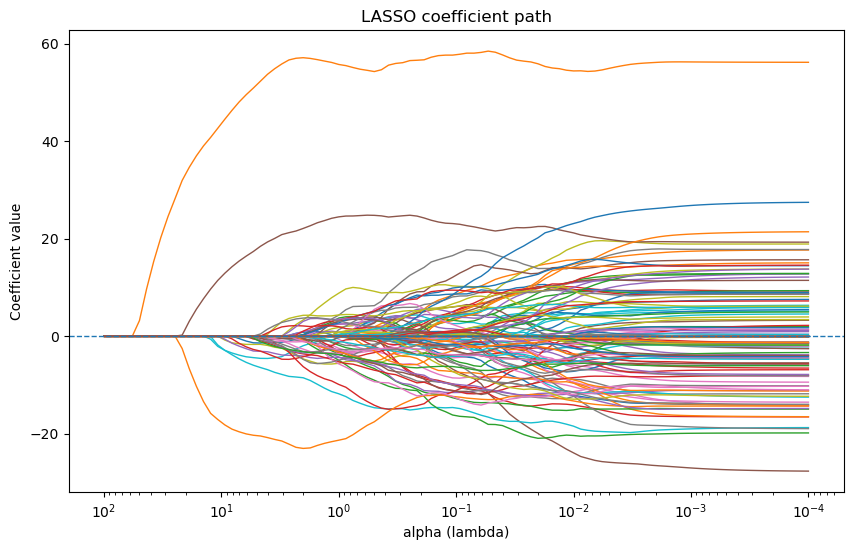

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import lasso_path

cat_cols = ["C_01", "C_02", "C_03", "C_04", "C_05"]

# -----------------------------
# Prepare X for LASSO
# -----------------------------
X_plot = X.copy()

for c in cat_cols:
    if c in X_plot.columns:
        X_plot[c] = X_plot[c].astype("string").fillna("Missing")

X_plot = pd.get_dummies(X_plot, dummy_na=True).astype(float)

feature_names = X_plot.columns

# impute + scale
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = imputer.fit_transform(X_plot)
X_scaled = scaler.fit_transform(X_imp)

y_array = np.asarray(y)

# -----------------------------
# Compute LASSO path
# -----------------------------
alphas_lasso = np.logspace(-4, 2, 100)

alphas_path, coefs_path, _ = lasso_path(
    X_scaled,
    y_array,
    alphas=alphas_lasso
)

# coefs_path shape = (n_features, n_alphas)

# -----------------------------
# Plot coefficient paths
# -----------------------------
plt.figure(figsize=(10, 6))

for i in range(coefs_path.shape[0]):
    plt.plot(alphas_path, coefs_path[i], linewidth=1)

plt.xscale("log")
plt.gca().invert_xaxis()   # large alpha on left, small alpha on right
plt.xlabel("alpha (lambda)")
plt.ylabel("Coefficient value")
plt.title("LASSO coefficient path")
plt.axhline(0, linestyle="--", linewidth=1)
plt.show()